In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from pathlib import Path
import random

In [ ]:
!pip install livelossplot

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from livelossplot.tf_keras import PlotLossesCallback
from tensorflow.keras.preprocessing.image import ImageDataGenerator

1. Data Preprocessing

1.1. Data Loading

In [ ]:
os.chdir("/content/Forest cover segmentation")

data_file = pd.read_csv("meta_data.csv", delimiter=',')
data_file.head()

,image,mask
0,1_sat.jpg,1_mask.jpg
1,2_sat.jpg,2_mask.jpg
2,3_sat.jpg,3_mask.jpg
3,4_sat.jpg,4_mask.jpg
4,5_sat.jpg,5_mask.jpg


1.2. Create Paths For Each File

In [ ]:
train_dir = 'images'
validation_dir = 'masks'

data_file['image'] = train_dir + '/' + data_file['image']
data_file['mask'] = validation_dir + '/' + data_file['mask']

1.3. Loading Data Into Memory

In [ ]:
image = np.array([plt.imread(data_file['image'][i]).astype(np.float32) / 256. for i in range(8)])
mask = np.array([(plt.imread(data_file['mask'][i]).astype(np.float32) / 256.)[:, :, 1] for i in range(8)])

In [ ]:
image.shape

(8, 256, 256, 3)

In [ ]:
mask.shape

(8, 256, 256)

1.4. Take a Look At Our Original Data

In [ ]:
def show_img(img, nrows=2, ncols=2, figsize=(10, 8)):
  fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
  id_img = 0
  for i in range(nrows):
    for j in range(ncols):
      ax[i][j].imshow(img[id_img])
      id_img += 1

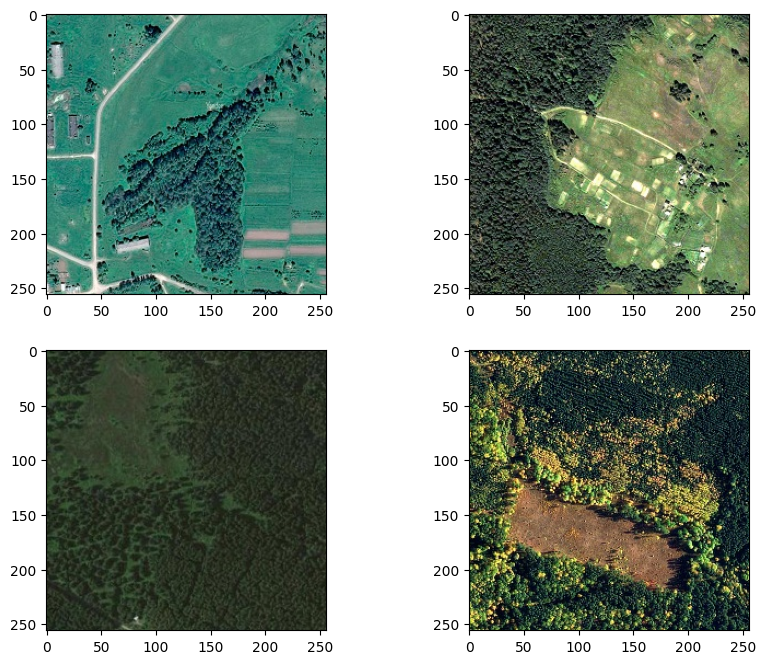

In [ ]:
show_img(image)

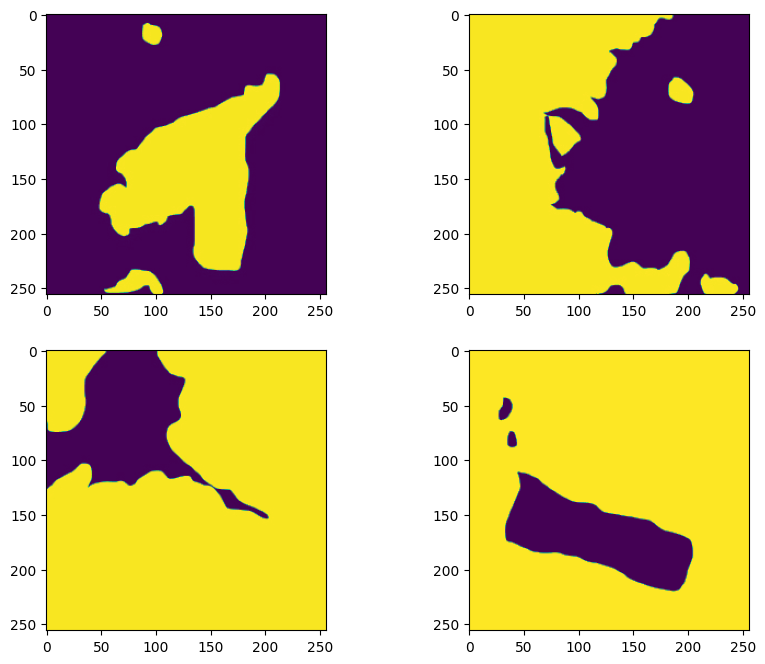

In [ ]:
show_img(mask)

2. Create Model

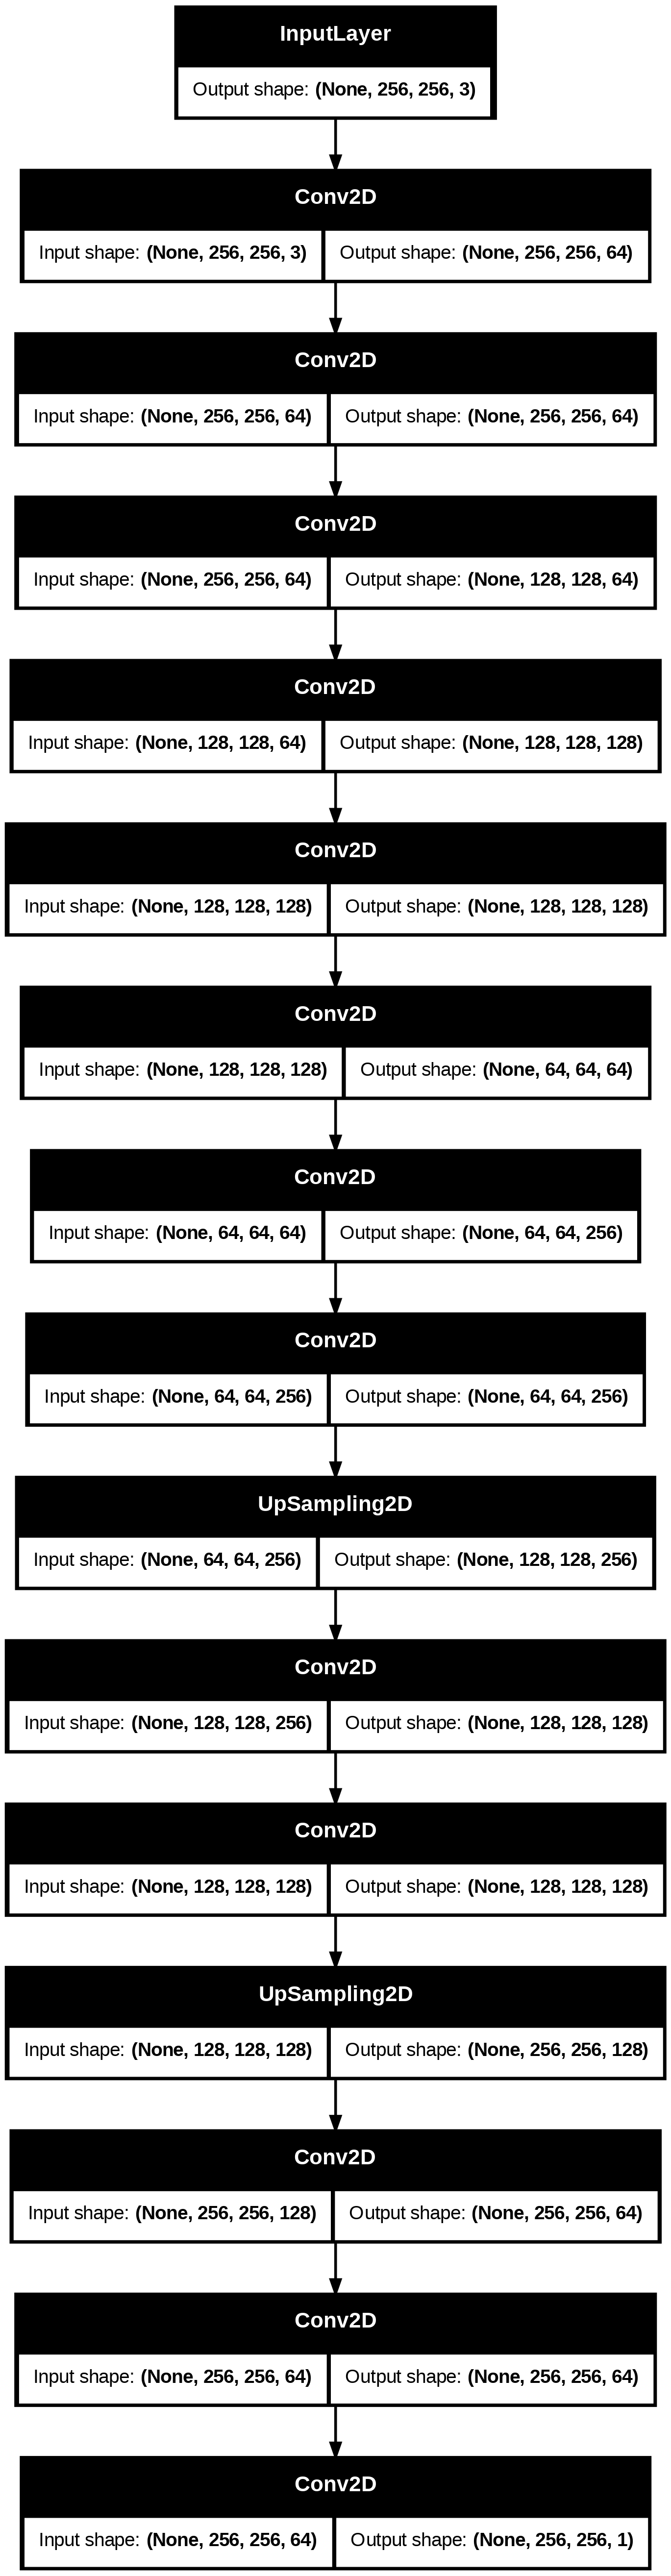

In [ ]:
x = tf.keras.layers.Input((256, 256, 3))

# Encoder
out = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
out = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')(out)

# Decoder
out = tf.keras.layers.UpSampling2D((2, 2))(out)
out = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.UpSampling2D((2, 2))(out)
out = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(out)
out = tf.keras.layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')(out)

model = tf.keras.Model(inputs=x, outputs=out)

tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
loss = tf.keras.losses.BinaryCrossentropy()
model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

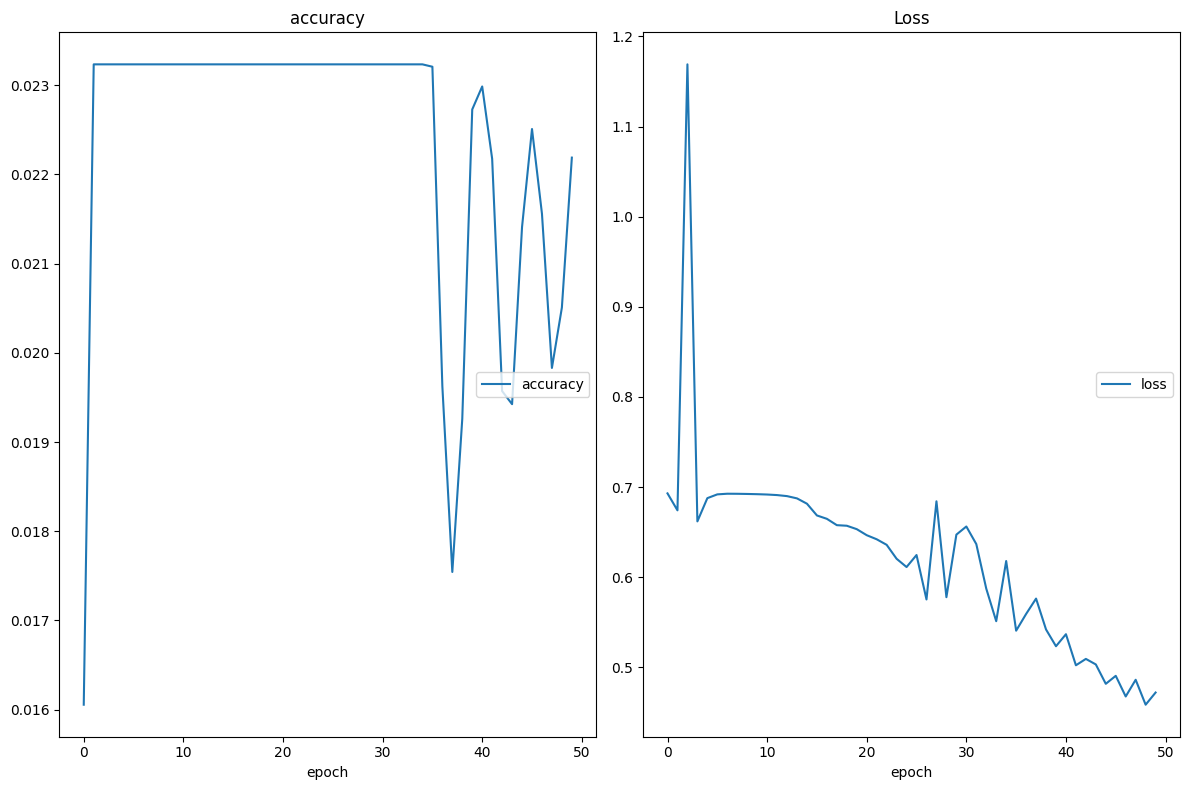

accuracy
	accuracy         	 (min:    0.016, max:    0.023, cur:    0.022)
Loss
	loss             	 (min:    0.459, max:    1.169, cur:    0.472)
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - accuracy: 0.0222 - loss: 0.4721


In [ ]:
history = model.fit(image, mask, batch_size=10, epochs=50, callbacks=[PlotLossesCallback()])

5. Showing The Result

In [ ]:
def show_img(img, model, nrows=2, ncols=2, figsize=(10, 8)):
  fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
  id_img = 0
  for i in range(nrows):
    for j in range(ncols):
      out = model.predict(img[id_img][None, ...])
      seg_map = (out[0, ..., 0]>0.5).astype(np.float32)
      seg_map_clr = plt.get_cmap('jet')(seg_map)[..., :3]
      ax[i][j].imshow(img[id_img]*0.5 + seg_map_clr*0.5)
      id_img += 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step


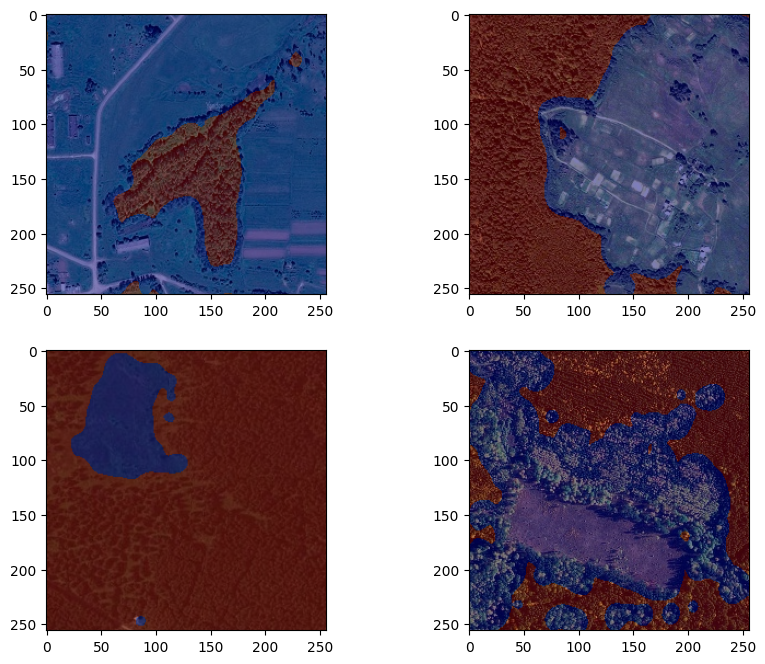

In [ ]:
show_img(image, model)